<a href="https://colab.research.google.com/github/tether007/DIP/blob/main/MPP_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

`Thermal Image
->
Simulated Damage
->
Mask Detection
->
Restored Image
->
PSNR / similarity score`

#1 . Initial data preprocessing
# Its basically sensor image -> detect corrupted part -> Mask gen -> prepare a Tensor rep. -> Feed it directly to DIP

In [1]:
import torch

# Device agnostic code

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
device

'cuda'

# 2 . Imports and necessary packages

In [10]:
import torch
from torch import nn
#vision libs
import torchvision

from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

#import visuaal stuff
import matplotlib.pyplot as plt
import cv2 as cv



In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deepnewbie/flir-thermal-images-dataset")

print("Path to dataset files:", path)

100%|██████████| 15.3G/15.3G [14:40<00:00, 18.6MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1


In [13]:
path

'/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1'

Checking path:
/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1/FLIR_ADAS_1_3/train/thermal_16_bit
Exists: True
Total TIFF files: 8862
Loading: /root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1/FLIR_ADAS_1_3/train/thermal_16_bit/FLIR_01656.tiff
Shape: (512, 640)
Datatype: uint16


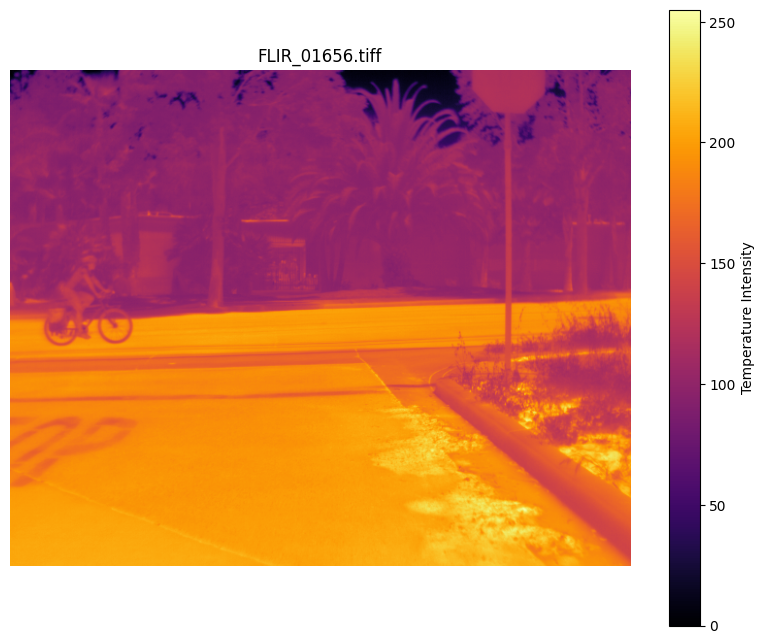

In [26]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_root = "/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1"

thermal_16_bit_dir = os.path.join(
    dataset_root,
    "FLIR_ADAS_1_3",
    "train",
    "thermal_16_bit"
)

print("Checking path:")
print(thermal_16_bit_dir)

print("Exists:", os.path.exists(thermal_16_bit_dir))

# List TIFF files
image_files = [
    f for f in os.listdir(thermal_16_bit_dir)
    if f.endswith(".tiff")
]

print("Total TIFF files:", len(image_files))

# Load first image
sample_image_path = os.path.join(
    thermal_16_bit_dir,
    image_files[0]
)

print("Loading:", sample_image_path)

# Read the image first
image = cv2.imread(sample_image_path, cv2.IMREAD_UNCHANGED)

print("Shape:", image.shape)
print("Datatype:", image.dtype)

# Normalising for thermal viz using the loaded image array
normalized = cv2.normalize(
    image, # Pass the image array
    None,
    0,
    255,
    cv2.NORM_MINMAX
)


plt.figure(figsize=(10,8))
plt.imshow(normalized, cmap='inferno')
plt.colorbar(label='Temperature Intensity')
plt.title(image_files[0])
plt.axis('off')
plt.show()

In [27]:
image  = cv2.imread(sample_image_path, cv2.IMREAD_UNCHANGED)

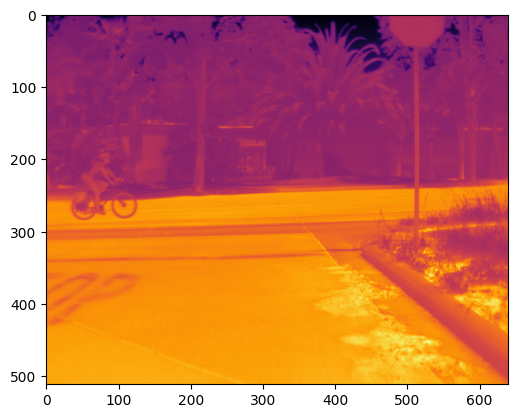

In [30]:
plt.imshow(image,cmap="inferno")

In [31]:
normalized = cv2.normalize(
    image,
    None,
    0,
    1,
    cv2.NORM_MINMAX,
    dtype=cv2.CV_32F
)

#3 . Adding Gausian noise to simulate for NOW

In [38]:
import numpy as np
noise = np.random.normal(0, 0.1, normalized.shape)

corrupted = normalized + noise
corrupted = np.clip(corrupted, 0, 1)

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

<Figure size 1000x700 with 0 Axes>

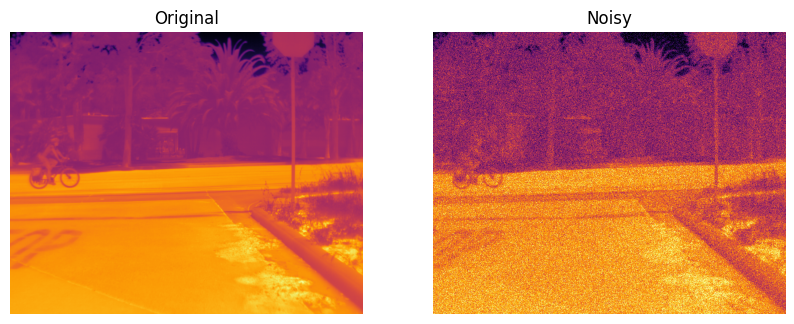

In [41]:
plt.figure(figsize=(10,7))
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# Original Image
axes[0].imshow(normalized, cmap='inferno')
axes[0].set_title("Original")
axes[0].axis('off')

# Noisy Image
axes[1].imshow(corrupted, cmap='inferno')
axes[1].set_title("Noisy")
axes[1].axis('off')


## 3.1 Adding missing(to simulate inpainting )

In [42]:
corrupted[150:300, 100:200] = 0

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

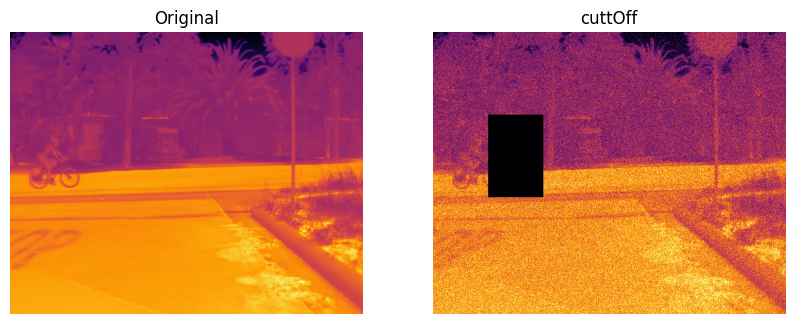

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# Original Image
axes[0].imshow(normalized, cmap='inferno')
axes[0].set_title("Original")
axes[0].axis('off')

# missing region Image
axes[1].imshow(corrupted, cmap='inferno')
axes[1].set_title("cuttOff")
axes[1].axis('off')

#4 . Creating a simple Mask for the given image
*. As simple as valid pixel -> 1, else 0





In [46]:
mask = (corrupted > 0).astype(np.float32)

In [47]:
mask

array([[0., 1., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)

# 5 . Img to Tensor (Highly crucial since it was numpy till now , but fro pytorch we need it in tensor)

* now we are worried about the "noiseful image"

## 5.1 . corr_Img -> tensor

In [48]:
image_tensor = torch.tensor(corrupted).float()

In [51]:
image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)# adding an extra dimension for W and H

## 5.2 . mask -> tensor

In [52]:
mask_tensor = torch.tensor(mask).float()

## 5.3 . org_img -> tensor

In [53]:
org_tensor = torch.tensor(image).float()

In [54]:
org_tensor = org_tensor.unsqueeze(0).unsqueeze(0)

##6 . Visualizing all the tensors
* Tensor to Numpy and then viz

<Figure size 1000x700 with 0 Axes>

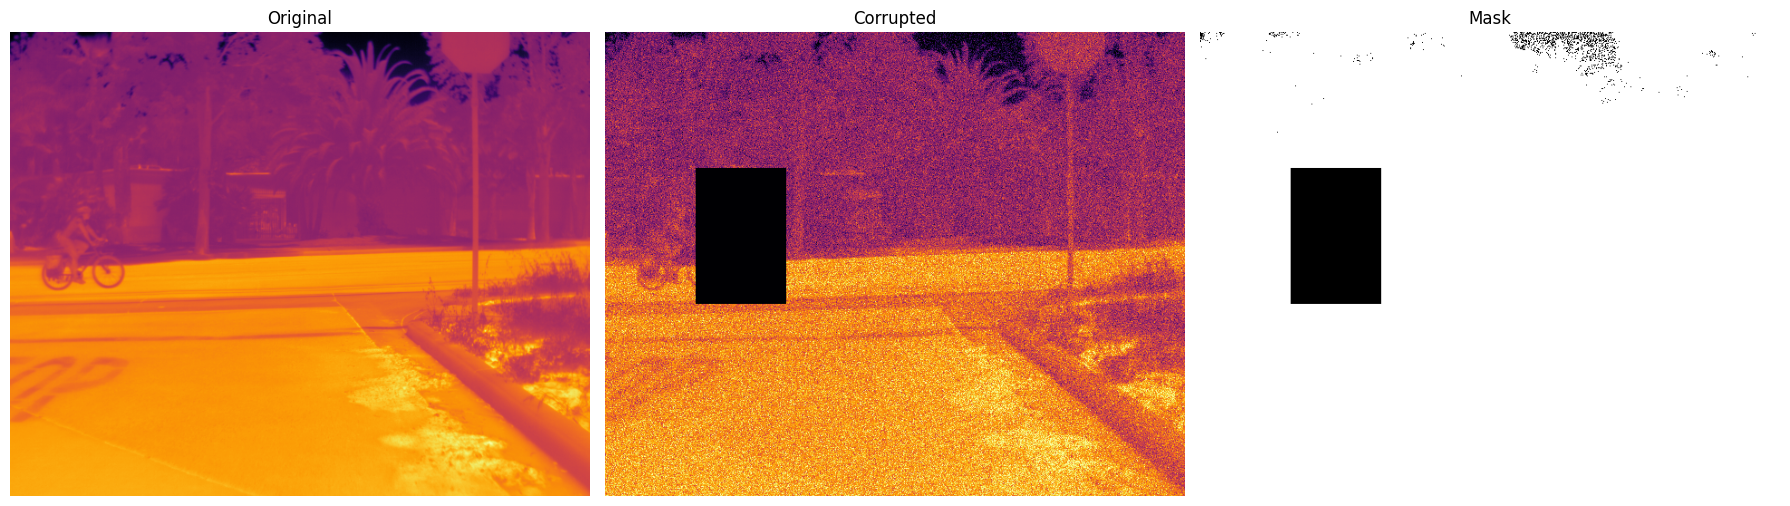

In [60]:
original_np = org_tensor.squeeze().cpu().numpy()
corrupted_np = image_tensor.squeeze().cpu().numpy()
mask_np = mask_tensor.squeeze().cpu().numpy()

plt.figure(figsize=(10,7))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
axes[0].imshow(original_np, cmap='inferno')
axes[0].set_title("Original")
axes[0].axis('off')

# Corrupted
axes[1].imshow(corrupted_np, cmap='inferno')
axes[1].set_title("Corrupted")
axes[1].axis('off')

# Mask
axes[2].imshow(mask_np, cmap='gray')
axes[2].set_title("Mask")
axes[2].axis('off')

plt.tight_layout()
plt.show()